# NOVAS IDEIAS PARA SEREM IMPLEMENTADAS

* https://pmc.ncbi.nlm.nih.gov/articles/PMC7206335/#Sec13 (falta ver se usa ou não préprocessamento)

* Cross validation

* Análise dos resultados

* Adicionar novas métricas para class imbalance (Gmean, etc)

* Distância de Mahalanobis

* LMKNN (é bom para outliers, não tanto para class imbalance) -> https://www.kaggle.com/code/baguspurnama/local-mean-based-knn-lmknn (feito)

* EasyEnsemble (feito)

Undersampling não é permitido 



# Imports

In [109]:
import numpy as np
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from pandas.api.types import is_numeric_dtype 
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product
import copy
from sklearn.metrics import (
    recall_score, 
    f1_score, 
    balanced_accuracy_score, 
    roc_auc_score, 
    average_precision_score
)
from sklearn.preprocessing import LabelBinarizer

np.random.seed(42) 

# KNNBase

Class base do knn dada pelos professores 

https://github.com/rushter/MLAlgorithms/blob/master/mla/knn.py

In [110]:
class KNNBase:
    def __init__(self, k=3):
        """
        Inicializa o classificador KNN.
        
        Parâmetros:
        k (int): O número de vizinhos a considerar.
        """
        self.k = k

    def fit(self, X, y):
        """
        'Treina' o modelo. No caso do KNN, apenas memorizamos os dados.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        """
        Faz a previsão para um conjunto de dados X.
        """
        X = np.array(X)
        # Calcula as previsões iterando sobre cada exemplo de teste
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        """
        Lógica interna para prever uma única amostra.
        É aqui que deves mexer se quiseres alterar o coração do algoritmo.
        """
        # 1. Calcular a distância Euclidiana entre 'x' e todos os pontos de treino.
        # Tiramos partido do NumPy (broadcasting) para fazer isto sem loops.
        distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

        # 2. Obter os índices dos K vizinhos mais próximos.
        # np.argpartition é mais rápido que np.argsort porque não ordena o array todo,
        # apenas garante que os 'k' menores ficam no início.
        k_indices = np.argpartition(distancias, self.k)[:self.k]

        # 3. Extrair as classes desses K vizinhos
        k_classes_vizinhas = self.y_train[k_indices]

        # 4. Votação por maioria: Qual é a classe mais comum?
        mais_comum = Counter(k_classes_vizinhas).most_common(1)
        
        return mais_comum[0][0]


# KNN com distâncias a considerar o peso de cada feature

(+) Information Gain -> (+) peso

dist = sqrt(IG * (xi-xt)**2)

Features que importam mais para determinar a target tem maior peso no calculo da distância

In [111]:
class KNN_features_weight(KNNBase):
    def __init__(self, k=3, num_bins=10):
        super().__init__(k=k)
        self.num_bins = num_bins
        self.pesos = None

    def _entropia(self, y):
        """Calcula o quão 'caótico' é um conjunto de classes."""
        _, contagens = np.unique(y, return_counts=True)
        probs = contagens / len(y)
        return -np.sum(probs * np.log2(probs))

    def fit(self, X, y):
        super().fit(X, y)
        n_features = self.X_train.shape[1]
        self.pesos = np.zeros(n_features)
        
        # 1. Entropia total do Target (Incerteza inicial)
        h_target = self._entropia(y)

        # 2. Calcular Information Gain para cada feature: IG = H(Target) - H(Target | Feature)
        for i in range(n_features):
            feat = self.X_train[:, i]
            # Divide a feature em 10 intervalos (baldes)
            bins = np.linspace(feat.min(), feat.max(), self.num_bins)
            indices_baldes = np.digitize(feat, bins)
            
            h_condicional = 0
            for b in np.unique(indices_baldes):
                y_no_balde = y[indices_baldes == b]
                peso = len(y_no_balde) / len(y)
                h_condicional += peso * self._entropia(y_no_balde)
            
            # Ganho de informação
            self.pesos[i] = h_target - h_condicional

        # 3. Normalizar pesos (opcional mas ajuda na escala da distância)
        if np.max(self.pesos) > 0:
            self.pesos /= np.max(self.pesos)

    def _predict_single(self, x):
        # Distância Euclidiana Ponderada: simples e direta
        diff_quadrada = (self.X_train - x) ** 2
        distancias = np.sqrt(np.sum(self.pesos * diff_quadrada, axis=1))

        k_indices = np.argpartition(distancias, self.k)[:self.k]
        return Counter(self.y_train[k_indices]).most_common(1)[0][0]

# KNN com class weight

In [112]:
class KNN_class_weight(KNNBase):
    def __init__(self, k=3):
        super().__init__(k=k)
        self.pesos_classes = {}

    def fit(self, X, y):
        # 1. Guarda os dados de treino usando o método da classe mãe
        super().fit(X, y)
        
        # 2. Conta as ocorrências de cada classe
        classes_unicas, contagens = np.unique(self.y_train, return_counts=True)
        total_amostras = len(self.y_train)
        num_classes = len(classes_unicas)
        
        # 3. Calcula o peso para cada classe (frequência inversa)
        for c, count in zip(classes_unicas, contagens):
            self.pesos_classes[c] = total_amostras / (num_classes * count)
            
        return self

    def _predict_single(self, x):
        # 1. Distância Euclidiana
        distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        
        # 2. Encontra os K vizinhos mais próximos
        k_indices = np.argpartition(distancias, self.k)[:self.k]
        votos = self.y_train[k_indices]
        
        # 3. Votação Ponderada
        contagem_ponderada = defaultdict(float)
        for voto in votos:
            contagem_ponderada[voto] += self.pesos_classes[voto]
            
        # 4. Retorna a classe com a maior soma de pesos
        return max(contagem_ponderada, key=contagem_ponderada.get)

# KNN com class weight e fetaure weight 

In [113]:
class KNN_Combined_Weight(KNN_features_weight):
    def __init__(self, k=3, num_bins=10):
        # Herda os atributos da versão de pesos de features
        super().__init__(k=k, num_bins=num_bins)
        self.pesos_classes = {}

    def fit(self, X, y):
        # 1. Executa o cálculo de entropia/pesos das colunas da classe mãe
        super().fit(X, y)
        
        # 2. Calcula os pesos das classes (frequência inversa)
        classes_unicas, contagens = np.unique(self.y_train, return_counts=True)
        total_amostras = len(self.y_train)
        num_classes = len(classes_unicas)
        
        for c, count in zip(classes_unicas, contagens):
            self.pesos_classes[c] = total_amostras / (num_classes * count)
            
        return self

    def _predict_single(self, x):
        # 1. Distância Euclidiana Ponderada pelas Features
        distancias = np.sqrt(np.sum(self.pesos * (self.X_train - x) ** 2, axis=1))
        
        # 2. Encontra os K vizinhos mais próximos
        k_indices = np.argpartition(distancias, self.k)[:self.k]
        votos = self.y_train[k_indices]
        
        # 3. Votação Ponderada pelas Classes O(K)
        contagem_ponderada = defaultdict(float)
        for voto in votos:
            contagem_ponderada[voto] += self.pesos_classes[voto]
            
        # 4. Retorna a classe vencedora
        return max(contagem_ponderada, key=contagem_ponderada.get)

# KNN com RBF Kernel, class e feature weight

In [114]:
class KNN_RBF(KNN_Combined_Weight):
    def __init__(self, k=3, num_bins=10, gamma=None):
        super().__init__(k=k, num_bins=num_bins)
        self.gamma = gamma

    def fit(self, X, y):
        super().fit(X, y)
        # Heurística padrão: se gamma não for fornecido, escala consoante o número de features
        if self.gamma is None:
            self.gamma = 1.0 / self.X_train.shape[1]
        return self

    def _predict_single(self, x):
        # 1. Distância ao Quadrado Ponderada pelas Features 
        distancias_sq = np.sum(self.pesos * (self.X_train - x) ** 2, axis=1)
        
        # 2. Encontra os K vizinhos rapidamente
        k_indices = np.argpartition(distancias_sq, self.k)[:self.k]
        votos = self.y_train[k_indices]
        
        # Guardamos as distâncias exatas desses K vizinhos
        distancias_k_sq = distancias_sq[k_indices]
        
        # 3. Calcula a Similaridade RBF APENAS para os K vizinhos (Eficiência máxima)
        similaridades_rbf = np.exp(-self.gamma * distancias_k_sq)
        
        # 4. Votação Ponderada: (Peso da Classe) * (Similaridade RBF)
        contagem_ponderada = defaultdict(float)
        for voto, sim_rbf in zip(votos, similaridades_rbf):
            contagem_ponderada[voto] += self.pesos_classes[voto] * sim_rbf
            
        return max(contagem_ponderada, key=contagem_ponderada.get)

### Conlusão sobre o RBF
A ideia seria dar mais peso a vizinhos mais próximos, mas não há melhoria significiativa (não nenhuma melhoria) em relação ao KNN_Combined_Weight e o tempo de execução aumenta. 

Ideia descartada.

# Threshold

In [115]:
class KNN_Threshold_Optimizer(KNNBase):
    def __init__(self, k=5, threshold=0.5):
        super().__init__(k=k)
        self.threshold = threshold
        self.min_class = None
        self.maj_class = None

    def fit(self, X, y):
        super().fit(X, y)
        # Identificar classe minoritária e maioritária
        contagens = Counter(self.y_train)
        classes_ordenadas = contagens.most_common()
        self.maj_class = classes_ordenadas[0][0]
        self.min_class = classes_ordenadas[-1][0]
        return self

    def predict_proba(self, X):
        X = np.array(X)
        probabilidades = []
        for x in X:
            distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argpartition(distancias, self.k)[:self.k]
            votos = self.y_train[k_indices]
            
            # Fração de votos que pertencem à classe minoritária
            prob_minoria = np.sum(votos == self.min_class) / self.k
            probabilidades.append(prob_minoria)
            
        return np.array(probabilidades)

    def predict(self, X, custom_threshold=None):
        thresh = custom_threshold if custom_threshold is not None else self.threshold
        probs = self.predict_proba(X)
        # Se a probabilidade da minoria for maior que o limiar, prevê minoria
        return np.where(probs >= thresh, self.min_class, self.maj_class)

# KNN com SMOTE

In [116]:
class KNN_Native_SMOTE(KNNBase):
    def __init__(self, k=5, oversample_ratio=1.0):
        super().__init__(k=k)
        self.oversample_ratio = oversample_ratio # 1.0 = igualar minoria à maioria

    def _apply_smote(self, X, y):
        classes, contagens = np.unique(y, return_counts=True)
        min_class = classes[np.argmin(contagens)]
        maj_class = classes[np.argmax(contagens)]
        
        n_maj = np.max(contagens)
        n_min = np.min(contagens)
        n_sinteticos_necessarios = int((n_maj - n_min) * self.oversample_ratio)
        
        if n_sinteticos_necessarios <= 0:
            return X, y
            
        X_min = X[y == min_class]
        amostras_sinteticas = []
        
        for _ in range(n_sinteticos_necessarios):
            # 1. Escolher um ponto minoritário aleatório
            idx_base = np.random.randint(0, len(X_min))
            ponto_base = X_min[idx_base]
            
            # 2. Encontrar o seu vizinho mais próximo dentro da PRÓPRIA minoria
            distancias = np.sum((X_min - ponto_base) ** 2, axis=1)
            distancias[idx_base] = np.inf # Ignorar o próprio ponto
            idx_vizinho = np.argmin(distancias)
            ponto_vizinho = X_min[idx_vizinho]
            
            # 3. Interpolar (criar ponto algures na linha entre os dois)
            gap = np.random.random()
            novo_ponto = ponto_base + (ponto_vizinho - ponto_base) * gap
            amostras_sinteticas.append(novo_ponto)
            
        X_sintetico = np.vstack([X, np.array(amostras_sinteticas)])
        y_sintetico = np.hstack([y, np.full(n_sinteticos_necessarios, min_class)])
        
        return X_sintetico, y_sintetico

    def fit(self, X, y):
        # Aplicamos SMOTE para equilibrar geometricamente ANTES de guardar o treino
        X_smote, y_smote = self._apply_smote(np.array(X), np.array(y))
        super().fit(X_smote, y_smote)
        return self

# Knn com vários tipos de Undersampling

In [117]:
class KNN_Selective_Wrapper:
    def __init__(self, modelo, random_state=42):
        self.modelo = modelo
        self.random_state = random_state

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        rng = np.random.default_rng(self.random_state)

        # --- 1. Identificar classes ---
        classes, contagens = np.unique(y, return_counts=True)
        classe_minoritaria = classes[np.argmin(contagens)]

        # --- 2. Separar minoritários e maioritários ---
        idx_min = np.where(y == classe_minoritaria)[0]
        idx_maj = np.where(y != classe_minoritaria)[0]

        # --- 3. Split de ambos: construção vs validação ---
        rng.shuffle(idx_min)
        rng.shuffle(idx_maj)

        split_min = int(len(idx_min) * 0.8)
        split_maj = int(len(idx_maj) * 0.8)

        idx_min_construcao = idx_min[:split_min]
        idx_min_validacao  = idx_min[split_min:]
        idx_maj_construcao = idx_maj[:split_maj]
        idx_maj_validacao  = idx_maj[split_maj:]

        # --- 4. Conjunto de validação fixo ---
        idx_val = np.concatenate([idx_min_validacao, idx_maj_validacao])
        X_val, y_val = X[idx_val], y[idx_val]

        # --- 5. Subconjunto inicial: minoritários de construção + 1 maioritário ---
        idx_construcao    = list(idx_min_construcao) + [idx_maj_construcao[0]]
        idx_maj_restantes = list(idx_maj_construcao[1:])

        # --- 6. Treino inicial e balanced accuracy base ---
        self.modelo.fit(X[idx_construcao], y[idx_construcao])
        melhor_score = self._balanced_accuracy(X_val, y_val)

        # --- 7. Loop — balanced accuracy decide tudo ---
        for idx in idx_maj_restantes:
            if melhor_score == 1.0:
                break

            novo_score = self._balanced_accuracy_temp(
                X, y, idx_construcao + [idx], X_val, y_val
            )

            if novo_score > melhor_score:  # estritamente maior
                idx_construcao = idx_construcao + [idx]
                self.modelo.fit(X[idx_construcao], y[idx_construcao])
                melhor_score = novo_score

        return self

    def predict(self, X):
        return self.modelo.predict(X)

    def _balanced_accuracy(self, X_val, y_val):
        preds = self.modelo.predict(X_val)
        classes = np.unique(y_val)
        recalls = []
        for c in classes:
            idx = y_val == c
            recalls.append(np.sum(preds[idx] == c) / np.sum(idx))
        return np.mean(recalls)

    def _balanced_accuracy_temp(self, X, y, idx_temp, X_val, y_val):
        X_bak, y_bak = self.modelo.X_train, self.modelo.y_train

        self.modelo.X_train = X[idx_temp]
        self.modelo.y_train = y[idx_temp]
        score = self._balanced_accuracy(X_val, y_val)

        self.modelo.X_train, self.modelo.y_train = X_bak, y_bak
        return score

In [118]:
class KNN_RUndersampling_Wrapper:
    """
    Wrapper que aplica Random Undersampling à classe maioritária 
    antes de treinar o modelo KNN base.
    """
    def __init__(self, modelo_base, random_state=None):
        self.modelo_base = modelo_base
        self.random_state = random_state

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        X_arr = np.array(X)
        y_arr = np.array(y)
        
        # 1. Identificar as classes e as suas frequências
        classes, contagens = np.unique(y_arr, return_counts=True)
        
        # Proteção: Se houver apenas 1 classe, passa direto
        if len(classes) < 2:
            self.modelo_base.fit(X_arr, y_arr)
            return self
            
        # 2. Determinar o limite pelo tamanho da classe minoritária
        min_count = np.min(contagens)
        
        indices_balanceados = []
        
        # 3. Extrair amostras aleatórias (sem reposição) para igualar a minoria
        for c in classes:
            indices_c = np.where(y_arr == c)[0]
            indices_amostrados = np.random.choice(indices_c, size=min_count, replace=False)
            indices_balanceados.extend(indices_amostrados)
            
        # 4. Baralhar os dados para evitar que o modelo aprenda padrões de ordem
        indices_balanceados = np.random.permutation(indices_balanceados)
        
        X_under = X_arr[indices_balanceados]
        y_under = y_arr[indices_balanceados]
        
        # 5. Delegar o treino no modelo base usando os dados equilibrados
        self.modelo_base.fit(X_under, y_under)
        return self

    def predict(self, X):
        # A previsão é inteiramente gerida pelo motor do modelo base
        return self.modelo_base.predict(X)

In [119]:
class KNN_NearMiss_Wrapper:
    def __init__(self, modelo_base):
        self.modelo_base = modelo_base

    def fit(self, X, y):
        X_arr = np.array(X)
        y_arr = np.array(y)
        
        classes, contagens = np.unique(y_arr, return_counts=True)
        if len(classes) < 2:
            self.modelo_base.fit(X_arr, y_arr)
            return self
            
        classe_minoria = classes[np.argmin(contagens)]
        classe_maioria = classes[np.argmax(contagens)]
        num_minoria = np.min(contagens)
        
        # 1. Separar os dados
        X_minoria = X_arr[y_arr == classe_minoria]
        X_maioria = X_arr[y_arr == classe_maioria]
        
        # 2. Calcular distância de TODOS da maioria para TODOS da minoria
        # Usando broadcasting do NumPy (similar ao teu KNNBase)
        # X_maioria tem shape (M, features), X_minoria tem (N, features)
        # Expansão para (M, 1, features) e (1, N, features) para diferença vetorizada
        distancias_sq = np.sum((X_maioria[:, np.newaxis, :] - X_minoria[np.newaxis, :, :]) ** 2, axis=2)
        
        # 3. Distância média de cada ponto maioritário aos seus vizinhos minoritários mais próximos
        # (Para ser rápido, calculamos a distância média a TODA a minoria, ou aos 3 mais próximos)
        distancias_medias = np.mean(distancias_sq, axis=1)
        
        # 4. Selecionar os índices da maioria com as MENORES distâncias
        indices_maioria_selecionados = np.argpartition(distancias_medias, num_minoria)[:num_minoria]
        
        # 5. Reconstruir o dataset balanceado
        X_under = np.vstack((X_minoria, X_maioria[indices_maioria_selecionados]))
        y_under = np.array([classe_minoria] * num_minoria + [classe_maioria] * num_minoria)
        
        # Baralhar e treinar
        indices_misturados = np.random.permutation(len(y_under))
        self.modelo_base.fit(X_under[indices_misturados], y_under[indices_misturados])
        return self

    def predict(self, X):
        return self.modelo_base.predict(X)

In [120]:
class KNN_TomekLinks_Wrapper:
    """
    Wrapper que aplica uma limpeza cirúrgica da fronteira de decisão.
    Identifica pares de instâncias de classes diferentes que são os vizinhos
    mais próximos um do outro (Tomek Links) e remove a amostra da classe maioritária.
    """
    def __init__(self, modelo_base):
        self.modelo_base = modelo_base

    def fit(self, X, y):
        X_arr = np.array(X)
        y_arr = np.array(y)
        
        # 1. Identificar as classes e a classe maioritária
        classes, contagens = np.unique(y_arr, return_counts=True)
        if len(classes) < 2:
            self.modelo_base.fit(X_arr, y_arr)
            return self
            
        classe_maioria = classes[np.argmax(contagens)]
        
        # 2. Matriz de Distâncias ao Quadrado O(N^2) vetorizada
        # Usamos (A-B)^2 = A^2 + B^2 - 2AB para máxima eficiência em vez de broadcasting direto
        X_sq = np.sum(X_arr ** 2, axis=1)
        # Produto escalar X * X.T
        dist_matrix = X_sq[:, np.newaxis] + X_sq[np.newaxis, :] - 2 * np.dot(X_arr, X_arr.T)
        
        # Garantir que não há valores negativos minúsculos devido a imprecisão de floating point
        dist_matrix = np.maximum(dist_matrix, 0)
        
        # 3. Impedir que um ponto seja vizinho de si mesmo (diagonal = infinito)
        np.fill_diagonal(dist_matrix, np.inf)
        
        # 4. Encontrar o índice do 1º vizinho mais próximo (1-NN) para CADA ponto
        nn_indices = np.argmin(dist_matrix, axis=1)
        
        # 5. Caça aos Tomek Links
        indices_a_remover = set()
        
        for i, j in enumerate(nn_indices):
            # Condição 1: São vizinhos mútuos (j é o mais próximo de i, e i é o mais próximo de j)
            # Condição 2: Pertencem a classes diferentes
            if nn_indices[j] == i and y_arr[i] != y_arr[j]:
                # Remover apenas o ponto que pertence à classe maioritária
                if y_arr[i] == classe_maioria:
                    indices_a_remover.add(i)
                if y_arr[j] == classe_maioria:
                    indices_a_remover.add(j)
                    
        # 6. Filtrar o dataset (manter apenas os que NÃO estão na lista de remoção)
        mascara_manter = np.ones(len(y_arr), dtype=bool)
        mascara_manter[list(indices_a_remover)] = False
        
        X_clean = X_arr[mascara_manter]
        y_clean = y_arr[mascara_manter]
        
        # 7. Delegar o treino no modelo base com os dados geometricamente limpos
        self.modelo_base.fit(X_clean, y_clean)
        return self

    def predict(self, X):
        return self.modelo_base.predict(X)

# CLMKNN

In [121]:
class KNN_Classwise_Local_Mean(KNNBase):
    def __init__(self, k=3):
        super().__init__(k=k)

    def _predict_single(self, x):
        # 1. Calcular distâncias de x a TODOS os pontos de treino
        distancias = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        
        classes = np.unique(self.y_train)
        distancias_aos_centroides = []
        
        for c in classes:
            # 2. Isolar espacialmente a classe atual
            mask_c = (self.y_train == c)
            X_c = self.X_train[mask_c]
            dist_c = distancias[mask_c]
            
            # Garantia de segurança: se k for maior que os dados da classe minoritária
            k_real = min(self.k, len(X_c))
            
            # 3. Encontrar os índices dos k vizinhos mais próximos DESTA classe
            k_indices_c = np.argpartition(dist_c, k_real - 1)[:k_real]
            vizinhos_c = X_c[k_indices_c]
            
            # 4. Criar o Centroide Local (Média Geométrica)
            centroide_local = np.mean(vizinhos_c, axis=0)
            
            # 5. Calcular a distância do nosso ponto original ao novo centroide
            dist_ao_centroide = np.sqrt(np.sum((centroide_local - x) ** 2))
            distancias_aos_centroides.append((c, dist_ao_centroide))
            
        # 6. A classe vencedora é a do centroide que estiver mais perto
        classe_prevista = min(distancias_aos_centroides, key=lambda item: item[1])[0]
        
        return classe_prevista

# EasyEssemble

In [122]:
class EasyEnsemble_Wrapper:
    """
    Wrapper Meta-Estimador para resolver o desequilíbrio de classes (Imbalanced Data).
    
    Estratégia (Defesa Académica): Em vez de destruir dados da classe maioritária 
    (undersampling clássico), cria um comitê de 'n' modelos, garantindo que toda 
    a informação da classe maioritária é explorada ao longo do conjunto de modelos.
    """
    def __init__(self, base_estimator, n_estimators=10):
        # O modelo algorítmico base que vai ser clonado (ex: o teu KNNBase)
        self.base_estimator = base_estimator
        # Quantos sub-modelos queremos no nosso comitê
        self.n_estimators = n_estimators
        self.estimators = []
        
        # Metadados essenciais para compatibilidade da API
        self.min_class = None
        self.maj_class = None
        self.classes_ = None 

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.estimators = []
        
        # Guardar a ordem natural das classes para a formatação do predict_proba
        self.classes_ = np.unique(y) 
        
        # 1. Identificar matematicamente a maioria e a minoria
        contagens = Counter(y)
        classes_ordenadas = contagens.most_common()
        self.maj_class = classes_ordenadas[0][0]
        self.min_class = classes_ordenadas[-1][0]
        
        # 2. Isolar os dados no espaço vetorial
        X_min = X[y == self.min_class]
        y_min = y[y == self.min_class]
        X_maj = X[y == self.maj_class]
        y_maj = y[y == self.maj_class]
        
        n_min = len(X_min)
        n_maj = len(X_maj)
        
        # 3. Construir o Ensemble
        for _ in range(self.n_estimators):
            # Proteção: Se não houver desequilíbrio, não fazemos amostragens
            if n_min >= n_maj:
                X_subset, y_subset = X, y
            else:
                # Amostragem sem reposição (replace=False) da classe maioritária
                # Extraímos exatamente o mesmo número de elementos da classe minoritária
                idx_maj = np.random.choice(n_maj, size=n_min, replace=False)
                X_maj_sample = X_maj[idx_maj]
                y_maj_sample = y_maj[idx_maj]
                
                # Fundir os dados num subconjunto perfeitamente balanceado (50/50)
                X_subset = np.vstack((X_min, X_maj_sample))
                y_subset = np.hstack((y_min, y_maj_sample))
                
                # Baralhar a ordem dos dados no array para evitar viés posicional
                idx_shuffle = np.random.permutation(len(y_subset))
                X_subset = X_subset[idx_shuffle]
                y_subset = y_subset[idx_shuffle]
            
            # MAGIA: Clonar o modelo base de forma isolada na memória
            # Isto garante que o KNNBase injetado não é reescrito a cada iteração
            modelo_clone = copy.deepcopy(self.base_estimator)
            modelo_clone.fit(X_subset, y_subset)
            self.estimators.append(modelo_clone)
            
        return self

    def predict_proba(self, X):
        X = np.array(X)
        
        # 1. Extrair os "hard votes" (previsões de classe direta) de todos os estimadores
        # O shape resultante será (n_estimators, n_samples)
        previsoes_votos = np.array([est.predict(X) for est in self.estimators])
        
        probabilidades = []
        
        # 2. Avaliar os votos coluna a coluna (amostra a amostra)
        for i in range(previsoes_votos.shape[1]):
            votos_amostra = previsoes_votos[:, i]
            
            # 3. Calcular a percentagem de votos para TODAS as classes.
            # Isto garante que a matriz final tem o shape exigido pelo scikit-learn (n_samples, 2).
            # Evita o crash silencioso (IndexError) no extrair do ROC-AUC/PR-AUC.
            probs_amostra = [np.sum(votos_amostra == c) / self.n_estimators for c in self.classes_]
            probabilidades.append(probs_amostra)
            
        return np.array(probabilidades)

    def predict(self, X):
        probs = self.predict_proba(X)
        
        # A classe vencedora é aquela com maior probabilidade no painel de modelos
        # O argmax olha para a linha (axis=1) e devolve o índice da maior percentagem
        indices_vencedores = np.argmax(probs, axis=1)
        
        # Mapeamos o índice de volta para o nome original da classe
        return self.classes_[indices_vencedores]

# Class para Normalização dos dados

In [123]:
class NormalizadorZScore:
    def __init__(self):
        self.medias = None
        self.desvios = None
        
    def fit(self, X):
        X_arr = np.array(X)
        # Calcula a média e desvio padrão por coluna (feature)
        self.medias = np.mean(X_arr, axis=0)
        self.desvios = np.std(X_arr, axis=0)
        
        # Proteção contra divisão por zero em colunas constantes
        self.desvios[self.desvios == 0] = 1e-8
        return self
        
    def transform(self, X):
        X_arr = np.array(X)
        # Aplica a fórmula: Z = (X - média) / desvio
        return (X_arr - self.medias) / self.desvios
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# Split

In [124]:
# Configurações
pasta_datasets = "mini_test_class" #"class_imbalance"
random_seed = 42
dados_preparados = {}

for ficheiro in os.listdir(pasta_datasets):
    if ficheiro.endswith(".csv"):
        # 1. Carregar o dataset
        df = pd.read_csv(os.path.join(pasta_datasets, ficheiro))
        
        # 2. Separar as features (X) do target (y)
        X = df.iloc[:, :-1].copy() # Usar .copy() evita alguns warnings do pandas
        y = df.iloc[:, -1].values  
        
        # 3. Lidar com valores nulos no X de forma segura
        for col in X.columns:
            if is_numeric_dtype(X[col]):
                # Se for número, preenche com a mediana
                X[col] = X[col].fillna(X[col].median())
            else:
                # Se for texto/categoria, preenche com o valor mais frequente (Moda)
                valor_mais_comum = X[col].mode()[0]
                X[col] = X[col].fillna(valor_mais_comum)
        
        # 4. Converter tudo o que é texto para números binários (0 e 1)
        X = pd.get_dummies(X, drop_first=True, dtype=int).values
        
        # 5. Fazer o split final
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_seed, stratify=y
        )
        
        # 6. NORMALIZAÇÃO Z-SCORE
        scaler = NormalizadorZScore()
        
        # Ajustamos só os dados de treino
        X_train_scaled = scaler.fit_transform(X_train)
        
        # Transformamos o teste cegamente para evitar Data Leakage
        X_test_scaled = scaler.transform(X_test)
        
        nome_base = ficheiro.replace(".csv", "")
        
        # Substituímos as matrizes brutas pelas matrizes escaladas no dicionário
        dados_preparados[nome_base] = (X_train_scaled, X_test_scaled, y_train, y_test)

print("Pré-processamento e Normalização concluídos! Datasets prontos:")
for nome, (X_tr, _, _, _) in dados_preparados.items():
    print(f"- {nome}: {X_tr.shape[1]} features")

Pré-processamento e Normalização concluídos! Datasets prontos:
- dataset_1013_analcatdata_challenger: 2 features
- dataset_311_oil_spill: 49 features
- dataset_316_yeast_ml8: 116 features


# Testar modelos

In [125]:
# 1. Lista com as versões do KNN
modelos = [
    ("KNNBase", KNNBase(k=3)),
    ("KNN_Base_SELECTIVE", KNN_Selective_Wrapper(KNNBase(k=3))),
    ("KNN_EasyEnsemble", EasyEnsemble_Wrapper(KNNBase(k=3), n_estimators=10)),

    ("KNN_features_weight", KNN_features_weight(k=3, num_bins=10)),
    ("KNN_features_weight_SELECTIVE", KNN_Selective_Wrapper(KNN_features_weight(k=3, num_bins=10))),
    ("KNN_features_weight_EasyEnsemble", EasyEnsemble_Wrapper(KNN_features_weight(k=3, num_bins=10), n_estimators=10)),
    
    ("KNN_class_weight", KNN_class_weight(k=3)),
    ("KNN_class_weight_SELECTIVE", KNN_Selective_Wrapper(KNN_class_weight(k=3))),
    ("KNN_class_weight_EasyEnsemble", EasyEnsemble_Wrapper(KNN_class_weight(k=3), n_estimators=10)),
    
    
    ("KNN_Combined_Weight", KNN_Combined_Weight(k=3, num_bins=10)),
    ("KNN_Combined_Weight_SELECTIVE", KNN_Selective_Wrapper(KNN_Combined_Weight(k=3, num_bins=10))),
    ("KNN_Combined_Weight_EasyEnsemble", EasyEnsemble_Wrapper(KNN_Combined_Weight(k=3, num_bins=10), n_estimators=10)),
    
    ("KNN_RBF", KNN_RBF(k=3, num_bins=10)),
    ("KNN_RBF_SELECTIVE", KNN_Selective_Wrapper(KNN_RBF(k=3, num_bins=10))),
    ("KNN_RBF_EasyEnsemble", EasyEnsemble_Wrapper(KNN_RBF(k=3, num_bins=10), n_estimators=10)),

    ("KNN_Threshold_Optimizer", KNN_Threshold_Optimizer(k=5, threshold=0.2)),
    ("KNN_Threshold_Optimizer_EasyEnsemble", EasyEnsemble_Wrapper(KNN_Threshold_Optimizer(k=5, threshold=0.2), n_estimators=10)),

    ("KNN_Classwise_Local_Mean", KNN_Classwise_Local_Mean(k=3)),
    ("KNN_Classwise_Local_Mean_SELECTIVE", KNN_Selective_Wrapper(KNN_Classwise_Local_Mean(k=3))),
    ("KNN_Classwise_Local_Mean_EasyEnsemble", EasyEnsemble_Wrapper(KNN_Classwise_Local_Mean(k=3), n_estimators=10)),
]

In [126]:
def avaliar_modelo(nome_modelo, modelo, nome_data, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # 1. Dicionário unificado e limpo logo no início
    resultados = {
        "Modelo": nome_modelo,
        "Dataset": nome_data,
        "Recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='macro', zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": np.nan,  # Inicializado como "falha" por defeito
        "PR-AUC": np.nan    # Inicializado como "falha" por defeito
    }

    # 2. Calcular as métricas complexas
    try:
        classes = np.unique(y_train)
        is_binary = len(classes) == 2
        
        if hasattr(modelo, "predict_proba"):
            y_scores = modelo.predict_proba(X_test)
            if is_binary and y_scores.shape[1] == 2:
                y_scores = y_scores[:, 1]
        else:
            y_scores = LabelBinarizer().fit(classes).transform(y_pred)
            if is_binary:
                y_scores = y_scores.ravel()

        if is_binary:
            resultados["ROC-AUC"] = roc_auc_score(y_test, y_scores)
            resultados["PR-AUC"] = average_precision_score(y_test, y_scores)
        else:
            y_test_bin = LabelBinarizer().fit_transform(y_test)
            resultados["ROC-AUC"] = roc_auc_score(y_test, y_scores, multi_class='ovr', average='macro')
            resultados["PR-AUC"] = average_precision_score(y_test_bin, y_scores, average='macro')

    except Exception:
        # Se falhar (ex: só há 1 classe no teste), os NaNs definidos no início mantêm-se.
        pass

    return resultados

# 3. Execução Paralela
resultados_lista = Parallel(n_jobs=-1)(
    delayed(avaliar_modelo)(
        nome_mod, copy.deepcopy(mod), nome_data, X_train, X_test, y_train, y_test
    )
    for (nome_data, (X_train, X_test, y_train, y_test)), (nome_mod, mod) 
    in product(dados_preparados.items(), modelos)
)

# Resultados

In [127]:
df_resultados = pd.DataFrame(resultados_lista)
# Ordenar pelos melhores resultados de F1-Score ou Balanced Accuracy
df_resultados = df_resultados.sort_values(by="PR-AUC", ascending=False)
display(df_resultados)

,Modelo,Dataset,Recall,F1-Score,Balanced Accuracy,ROC-AUC,PR-AUC
11,KNN_Combined_Weight_EasyEnsemble,dataset_1013_analcatdata_challenger,0.807692,0.523810,0.807692,0.865385,0.333333
5,KNN_features_weight_EasyEnsemble,dataset_1013_analcatdata_challenger,0.653846,0.562500,0.653846,0.759615,0.312500
39,KNN_Classwise_Local_Mean_EasyEnsemble,dataset_311_oil_spill,0.788889,0.583484,0.788889,0.891319,0.307909
23,KNN_features_weight,dataset_311_oil_spill,0.684722,0.741758,0.684722,0.684722,0.307846
34,KNN_RBF_EasyEnsemble,dataset_311_oil_spill,0.845833,0.594004,0.845833,0.915972,0.277199
31,KNN_Combined_Weight_EasyEnsemble,dataset_311_oil_spill,0.851389,0.603689,0.851389,0.863889,0.269844
8,KNN_class_weight_EasyEnsemble,dataset_1013_analcatdata_challenger,0.673077,0.591837,0.673077,0.855769,0.266667
14,KNN_RBF_EasyEnsemble,dataset_1013_analcatdata_challenger,0.673077,0.591837,0.673077,0.846154,0.257576
6,KNN_class_weight,dataset_1013_analcatdata_challenger,0.884615,0.634783,0.884615,0.884615,0.250000
28,KNN_class_weight_EasyEnsemble,dataset_311_oil_spill,0.797222,0.597947,0.797222,0.870139,0.248106


/var/folders/36/5c0cj0lx2f9fxw9pmcwjhngh0000gn/T/ipykernel_54426/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


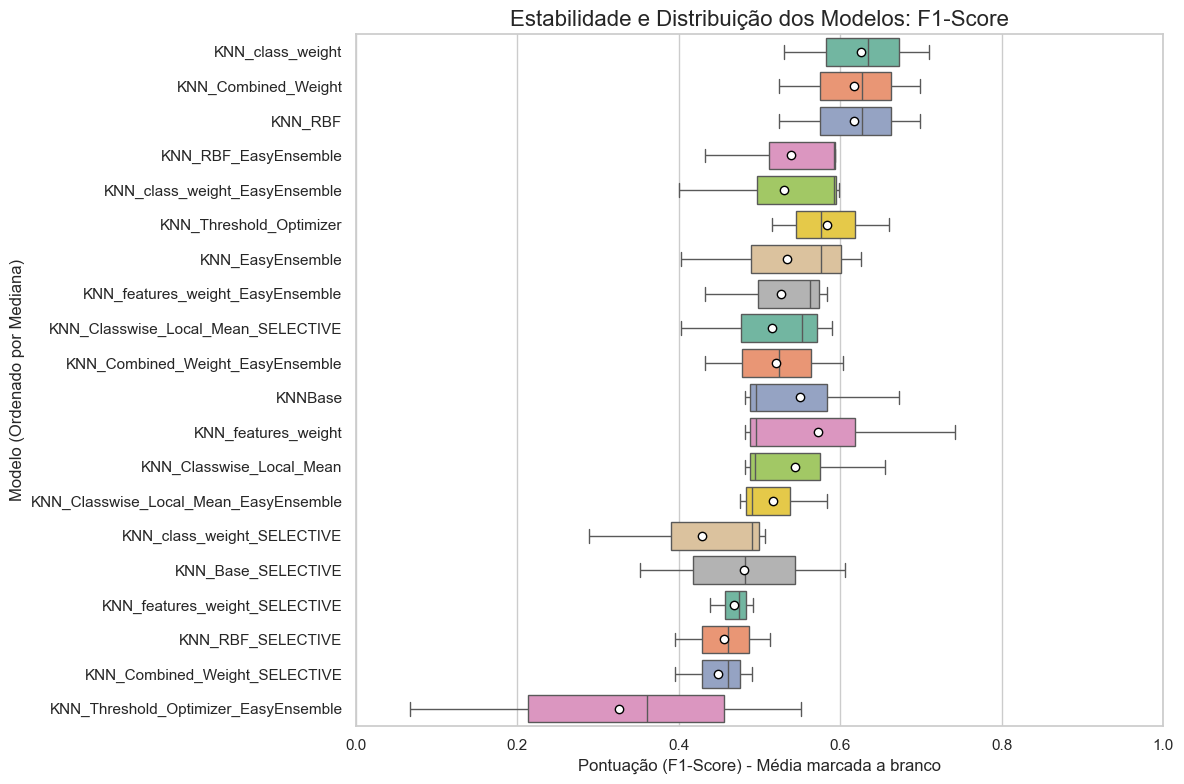

/var/folders/36/5c0cj0lx2f9fxw9pmcwjhngh0000gn/T/ipykernel_54426/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


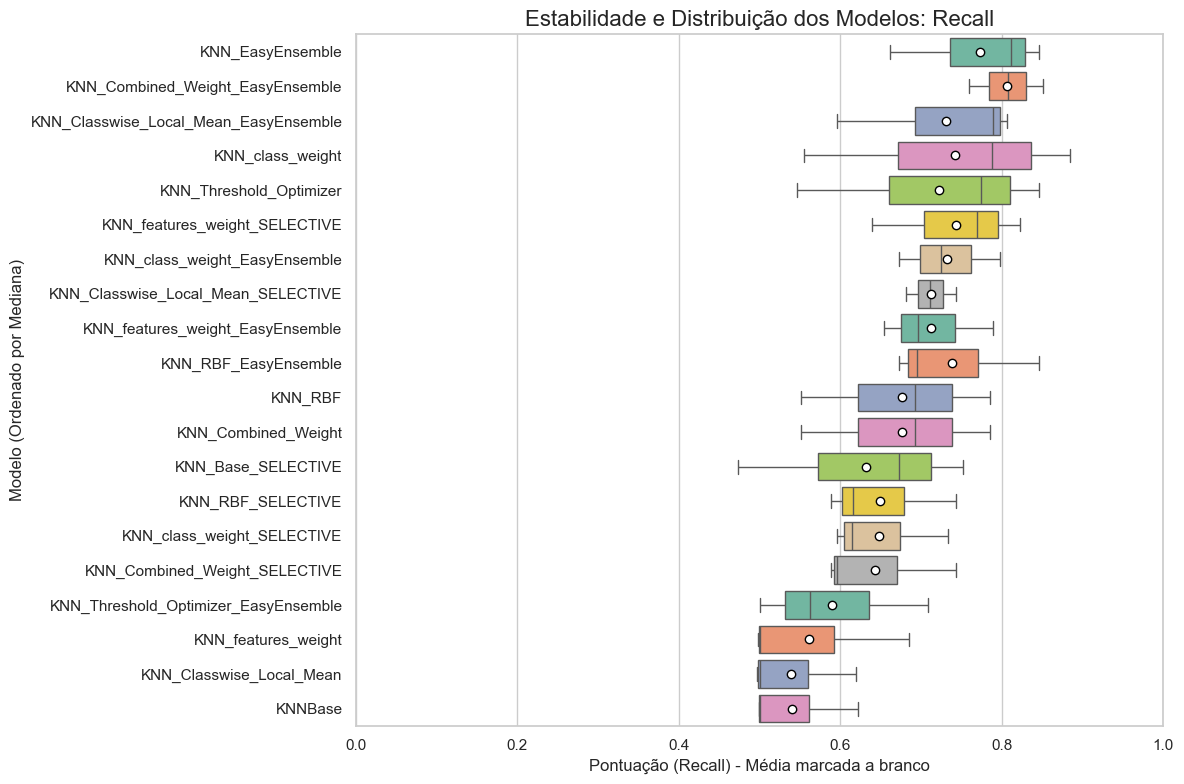

/var/folders/36/5c0cj0lx2f9fxw9pmcwjhngh0000gn/T/ipykernel_54426/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


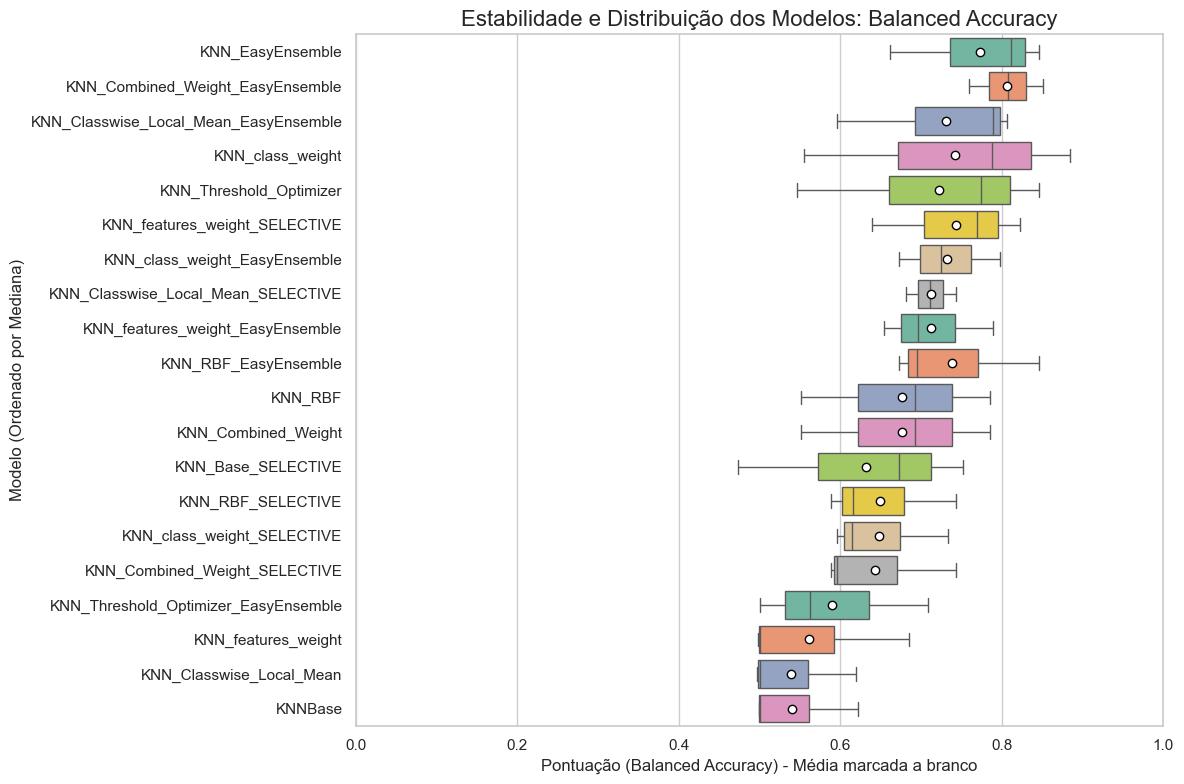

/var/folders/36/5c0cj0lx2f9fxw9pmcwjhngh0000gn/T/ipykernel_54426/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


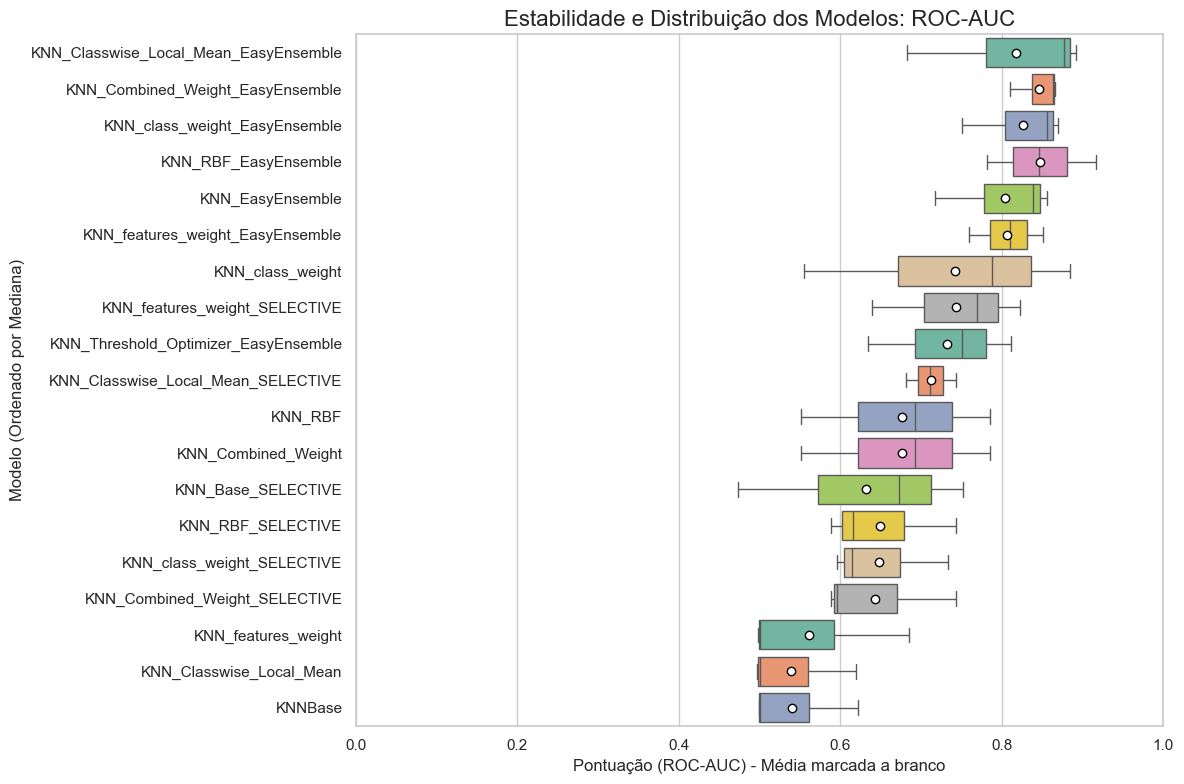

/var/folders/36/5c0cj0lx2f9fxw9pmcwjhngh0000gn/T/ipykernel_54426/3991804583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


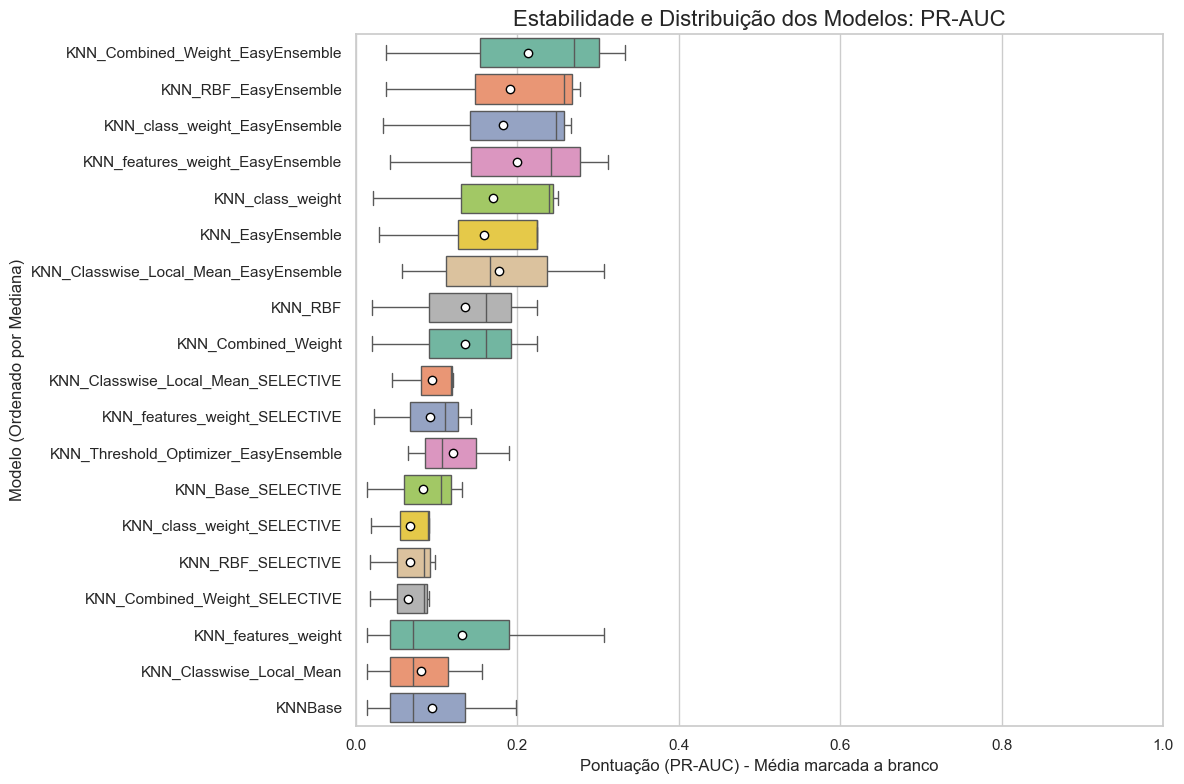

In [128]:
def plotar_distribuicao_modelos(df_resultados):
    metricas = ["F1-Score", "Recall", "Balanced Accuracy", "ROC-AUC", "PR-AUC"]
    sns.set_theme(style="whitegrid")
    
    paleta_clara = "Set2" 
    
    for metrica in metricas:
        if df_resultados[metrica].isna().all():
            print(f"Aviso: A métrica {metrica} só contém valores nulos e não será plotada.")
            continue

        num_modelos = len(df_resultados['Modelo'].unique())
        altura = max(6, num_modelos * 0.4)
        
        plt.figure(figsize=(12, altura))
        
        ordem = df_resultados.groupby('Modelo')[metrica].median().dropna().sort_values(ascending=False).index
        
        sns.boxplot(
            data=df_resultados,
            x=metrica,
            y="Modelo",
            order=ordem,
            palette=paleta_clara,
            showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
        )
        
        plt.title(f"Estabilidade e Distribuição dos Modelos: {metrica}", fontsize=16)
        plt.xlabel(f"Pontuação ({metrica}) - Média marcada a branco")
        plt.ylabel("Modelo (Ordenado por Mediana)")
        plt.xlim(0, 1)
        
        plt.tight_layout()
        plt.show()

plotar_distribuicao_modelos(pd.DataFrame(resultados_lista))